# Numerical Optimization

In [19]:
%pip install numpy matplotlib scipy statsmodels pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Introduction

A common task in statistics is maximizing (or minimizing) complex univariate or multivariate functions. This is typically done in the context of maximizing likelihood functions with respect to a vector of unknown parameters, given the observed data.

The term "parameter estimation" may be one that you may have commonly heard in the past during discussions of fitting statistical models to data. More generally, this task pertains to an "optimization" problem, where we seek to finding a set of parameter values that minimizes or maximizes some pre-defined objective function. When this objective function is a log likelihood function, this reduces to the problem of maximum likelihood estimation.

As we will see in this lecture, there are many potential approaches to use for optimization in this context. How best to optimize a function of interest depends on the nature of the function to be optimized, as well as practical concerns regarding a candidate procedure to be used. As such, another goal of this lecture is to explain the pros and cons of different approaches to help narrow down which approach may best for your particular problem.

Our discussion of optimization in this lecture will give a broad overview of existing approaches for unconstrained optimization, touching the many of the special cases that may have been covered in previous coursework. In a later lecture we will discuss the topic of "constrained" optimization, where the potential set of allowable solutions is no longer unrestricted. We focus on the class of problems where the function to be optimized is smooth, real valued, and is differentiable.

### Example: Height data
Let us assume that we have obtained a random sample of 100 individuals from Chapel Hill. Let us define $\mathbf{y} = (y_1,\ldots,y_{100})$, where $y_i$ pertains to the measured height of the $i^{th}$ individual in inches, for $i =1,\ldots,100$.

Let us further assume that the distribution of these heights is distributed normally with some unknown mean $\mu$ and **known** variance $\sigma^2 = 10$. That is, we assume that $y_i \sim N(\mu,\sigma^2)$, where $\sigma^2 = 10$.

A common question in this situation is what is the "best" estimate of $\mu$ given the data, and how do we obtain it? Answering this question can depend on the domain of the question being asked.

From introductory statistical courses, one may remember that an estimator for $\mu$, say $\hat{\mu}$ , in this setting may be $\bar{\mathbf{y}}$, or the mean of the observed heights. In more advanced statistical courses, you may have shown why this is the case via **analytically** deriving the maximum likelihood estimator for $\mu$, and proving its optimality relative to other potential estimators.

We can also re-express the original form of this problem as an intercept-only linear regression model:  $$y_i = \mathbf{X}_i\beta + \epsilon_i$$ where $\epsilon_i \sim N(0,\sigma^2)$, $\mathbf{X}_i = 1$, and $\beta = \mu$, a scalar parameter in this setting.  Again,  $\sigma^2$ is known in this case.   Given this, we can show that an estimate for $\beta$ ($\mu$) is also $\bar{\mathbf{y}}$. Based on the normal equations from the linear model framework, we have closed form solution $\hat{\beta} = (\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'\mathbf{y}$,  which, plugging in $\mathbf{X}$ and $\mathbf{y}$ from this situation, also yields $\bar{\mathbf{y}}$.

Regardless of the approach used here, we can show that we can obtain $\hat{\mu}$ analytically via optimizing some function of the data with respect to the parameter of interest $\mu$.  In the linear regression case, we are minimizing the residual sum of squares of the model with respect to $\beta$ ($\mu$), and in the latter, we are maximizing the likelihood function assumed for the data with respect to $\mu$.

#### Writing out the likelihood
The likelihood function $L(\boldsymbol{\theta})$, given the assumptions we made, for this sample can be written as

$$
\begin{align}
L(\boldsymbol{\theta}) &= f(y_1 | \mu, \sigma^2)f(y_2 | \mu, \sigma^2)\ldots f(y_{100} | \mu, \sigma^2)\\
  &= \prod_{i=1}^{100} f(y_i | \mu, \sigma^2)\\
  &= \frac{1}{(2\sigma^{2})^{n/2}}e^{-\frac{1}{2\sigma^2}\sum_{i=1}^{100}(y_i-\mu)^2}
\end{align}
$$

Here, $\boldsymbol{\theta} = \mu$ since we are assuming that $\sigma^2$ is known.  Taking logs of both sides, we can write the optimization of $L(\boldsymbol{\theta})$ above in terms of the optimization of $\mathcal{l}(\boldsymbol{\theta})$, the log-likelihood, as it is a monotonic transformation of the original likelihood function.

Why does this matter? This implies that the maximum of one function will be the maximum of the other function, as the log transformation is a one-to-one mapping from the likelihood to the log-likelihood (example in figure below).  Using approaches from prior courses, we can show that this function is smooth and convex in $\boldsymbol{\theta}$, and therefore the maximum of the log-likelihood (and hence the likelihood) will be attained at the value of $\boldsymbol{\theta}$ where the first derivative of $\mathcal{l}(\boldsymbol{\theta})$ is equal to zero.

In the current problem, the MLE for $\mu$, $\hat{\mu} = \bar{\mathbf{y}}$, is then obtained  by setting the 1st derivative of the log-likelihood (also known as the "score function") equal to 0 and then solving for $\mu$ (can you show this?).  In other words, we find the root of the score function with respect to $\mu$.  For the regression based approach, we are simply minimizing the residual sum of squares (RSS), defined as $\sum_{i = 1}^{100} (y_i - \mu)^2$.

In previous courses you may have found that this log transformation often facilitates the calculation of derivatives when analytically solving for $\mu$.  This approach of using another function as a proxy of the original function to simplify maximization can be found in several examples of optimization we will cover this semester.

#### Visualizing the optimization problem for $\mu$
We can illustrate this approach using the following simulation example:

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm
import time

## set simulation parameters
mu = 67
sigma2 = 10
n = 100

## generate random normally distributed samples
np.random.seed(42)
y = np.random.normal(mu, np.sqrt(sigma2), n)

## print MLE of mu, mu_hat
print("mean of y")
print(np.mean(y))

## print estimate of mu in linear model framework (intercept only model)
X = np.ones(n)
model = sm.OLS(y, X).fit()
print("beta_hat from intercept only linear model")
print(model.params[0])

mean of y
66.67160847795839
beta_hat from intercept only linear model
66.67160847795839


Now, lets write some functions to help generate some figures in the next code chunk. These functions will help plot the likelihood, log likelihood, and RSS with respect to $\mu$ based on the setup above.

In [21]:
## returns a vector of likelihood values over a given range of mu values
## helps for plotting later
def lik(mu_range, sigma2, y):
    likelihood_vector = np.array([
        np.prod(stats.norm.pdf(y, mu_val, np.sqrt(sigma2)))
        for mu_val in mu_range
    ])
    return likelihood_vector

## define the log-likelihood function with respect to mu
def loglik(mu_range, sigma2, y):
    log_likelihood_vector = np.array([
        np.sum(stats.norm.logpdf(y, mu_val, np.sqrt(sigma2)))
        for mu_val in mu_range
    ])
    return log_likelihood_vector

## define the residual sum of squares function with respect to mu
def RSS(mu_range, sigma2, y):
    rss_vector = np.array([
        np.sum((y - mu_val) ** 2)
        for mu_val in mu_range
    ])
    return rss_vector

Now that we got that out of the way, lets plot each of these functions with respect to $\mu$:

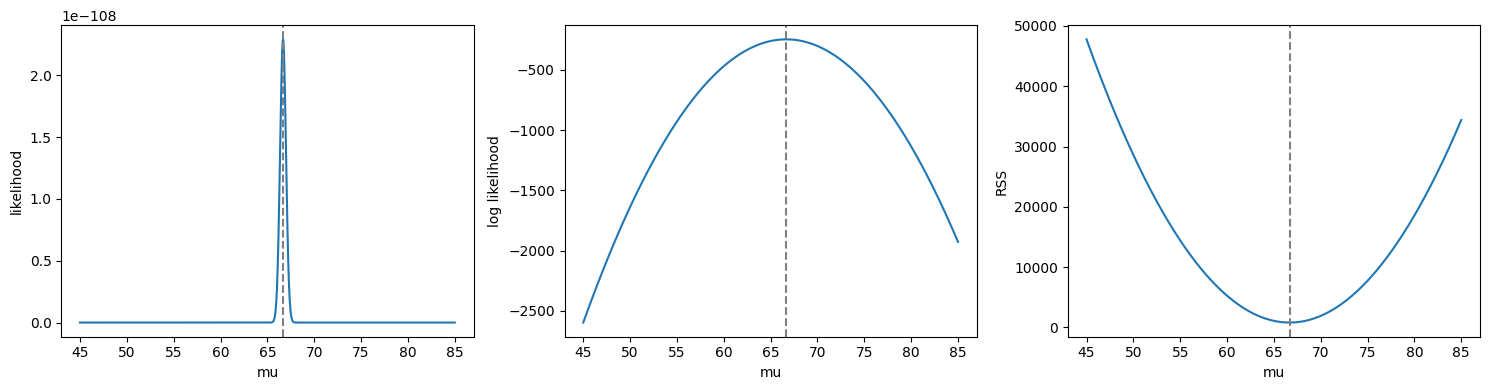

In [22]:
## range of mu to plot over
mu_range = np.linspace(45, 85, 1000)

## arrange the two plots in 1 row, three columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

## likelihood plot
axes[0].plot(mu_range, lik(mu_range, sigma2, y))
axes[0].set_ylabel("likelihood")
axes[0].set_xlabel("mu")
axes[0].axvline(np.mean(y), linestyle='--', color='grey')

## log likelihood plot
axes[1].plot(mu_range, loglik(mu_range, sigma2, y))
axes[1].set_ylabel("log likelihood")
axes[1].set_xlabel("mu")
axes[1].axvline(np.mean(y), linestyle='--', color='grey')

## RSS plot
axes[2].plot(mu_range, RSS(mu_range, sigma2, y))
axes[2].set_ylabel("RSS")
axes[2].set_xlabel("mu")
axes[2].axvline(np.mean(y), linestyle='--', color='grey')

plt.tight_layout()

We can clearly see that the maximum of the likelihood, log-likelihood, and RSS functions occurs at the MLE of $\mu$, $\hat{\mu} = \bar{y}$.  At the MLE, we can see that the derivative of each of the functions are equal to zero, following the intuition of the procedures used to solve for $\hat{\mu}$.  We will see that many of the algorithms proposed in this section are based upon this principle when trying to find the minimum/maximum of a function when no closed form solutions are available.

### Calculating the MLE for $\lambda$ for the mean of the Poisson Distribution

We know that the PMF for a Poisson random variable $Y$ with mean $\lambda$ may be written as $$Po(Y=y | \lambda) = \frac{e^{-\lambda}\lambda^y}{y!},$$ where $y$ is a draw from this distribution.  Suppose we draw a sample of $n$ observations from this distribution and we wish to determine the MLE of $\lambda$, $\hat{\lambda}$.

As discussed in prior courses, the MLE can be obtained by simply taking the first derivative of the likelihood (or more easily, the log likelihood), setting it equal to 0, and then solving for the parameter of interest.

The log likelihood here is $$\mathcal{l}(\lambda) = -n\lambda + \left(\sum_{i = 1}^{n} y_i \right)\log(\lambda) - \sum_{i = 1}^{n}\log(y_i!).$$ Then, taking the first derivative of the log likelihood, also known as the score function, we then solve the following:  $$0 = -n + \left(\sum_{i = 1}^{n} y_i \right)/\lambda$$ which gives the MLE $\hat{\lambda} = \left(\sum_{i = 1}^{n} y_i \right)/n$.

In this example, as in the prior one, we can derive closed form solutions to obtain a parameter estimate for $\lambda$ by maximizing log-likelihood function. You can imagine the task of optimization as not too different from that of root finding. In the context of maximum likelihood estimation, this is akin to finding the root of the score equation.

**However, what if we do not have such nice closed-form solutions for the model at hand?**

#### Something Less Straightforward: Poisson Regression

For example, what if instead $\lambda = \exp(\mathbf{X}\boldsymbol{\beta})$, where $\mathbf{X}$ is an $n \times p$ matrix of covariates, and $\boldsymbol{\beta}$ is a $p$-dimensional vector of unknown regression coefficients?  Here we wish to maximize the log likelihood with respect to $\boldsymbol{\beta}$.  This is equivalent to fitting a Poisson GLM, which we will talk about later in this lecture.

The log likelihood would then be $$\mathcal{l}(\boldsymbol{\beta}) =   \sum_{i=1}^n \left(y_iX_i\boldsymbol{\beta} -e^{\mathbf{X}_i\boldsymbol{\beta}}-\log(y_i!)\right).$$  Not so easy to obtain a closed form solution for the derivative here...

This problem gets at the heart of why we need to use numerical optimization.

## Univariate Optimization

In this module we will discuss some fundamental methods for the optimization of smooth nonlinear functions, beginning with single univariate functions and then discussing extensions to the multivariate case.  We will also cover the EM algorithm (Givens and Hoeting Chapter 4) in more detail in a later lecture.  There we will discuss the optimization of functions with missing data and also how the algorithm has been widely applied to general problems in statistics.

Let us consider the numerical optimization of the following function $f(\theta)$, which we seek to maximize with respect to $\theta$: $$f(\theta) = \frac{\log(\theta)}{1+\theta}.$$  The traditional approach to maximizing $f(\theta)$, such as the one described in the previous example, is difficult to apply here as the analytical solution for $\theta$ after setting $f'(\theta) = 0$  is not easy to determine.

Here,  $$f'(\theta) = \frac{1+\theta - \theta\log(\theta)}{\theta(1+\theta)^2}.$$ So...not easy to solve for.

Lets first plot this function to determine its shape:

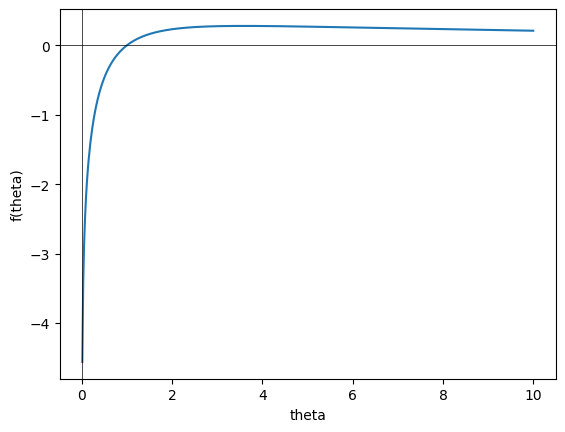

In [23]:
# define function
def f1(theta):
    return np.log(theta) / (1 + theta)

# make a plot with this function, where the x-axis ranges from 0 to 10
theta_range = np.linspace(0.01, 10, 500)
plt.figure()
plt.plot(theta_range, f1(theta_range))
plt.ylabel("f(theta)")
plt.xlabel("theta")
plt.axhline(y=0, color="k", linewidth=0.5)
plt.axvline(x=0, color="k", linewidth=0.5)
plt.savefig("figures/f1_plot.png", dpi=150, bbox_inches="tight")

Plotting this function, the maximum of $f(\theta)$ appears to be between 3 and 4. So how exactly do we find the maximum of this function, and the value of $\theta$ that pertains to the maximum, $\hat{\theta}$?

### Basics of Numerical Optimization

Most numerical optimization methods are **iterative** and rely on the concept of successive approximations to find the value of $\theta$ pertaining to the minimum or maximum of the function of interest.  Such algorithms require a **starting value** $\theta^{(0)}$, an initial guess for $\hat{\theta}$.

From this point, an algorithm will **iteratively update** its guess for $\hat{\theta}$ based on a predefined updating formula.  Each update may be referred to an "iteration".

Ideally, the value of $\hat{\theta} \rightarrow \theta^*$ as $t \rightarrow \infty$, where $t$ is the iteration number such that $t>0$ and $\theta^*$ is the "true" value of $\theta$ where the maximum of $f(\theta)$ is achieved.   That is, as the number of iterations increases, we hope that $\hat{\theta}$ will approach its true optimum $\theta^*$, or **converge** to $\theta^*$.

However, given the iterative updating nature of these algorithms, $\hat{\theta}$ will never equal value of $\theta^*$ exactly, and will only approach $\theta^*$ as $t$ increases.  As a result, we need to define criteria or **stopping rules** indicating that the algorithm has **converged**, indicating that $\hat{\theta}$ is reasonably close to the prior estimate of $\hat{\theta}$ within some **tolerance** or distance.  In some cases, the algorithm may converge to some value other than $\theta^*$, or may not converge at all.  We will discuss these situations later in this lecture.

#### Graphical Illustration

To illustrate an application of numerical optimization to $f(\theta)$ (introduced earlier), see the following plot.  Here, we utilized the commonly used Newton-Raphson algorithm to optimize $f(\theta)$.  In it, we choose a starting value $\theta^{(0)} = 0.25$  to initialize the algorithm.

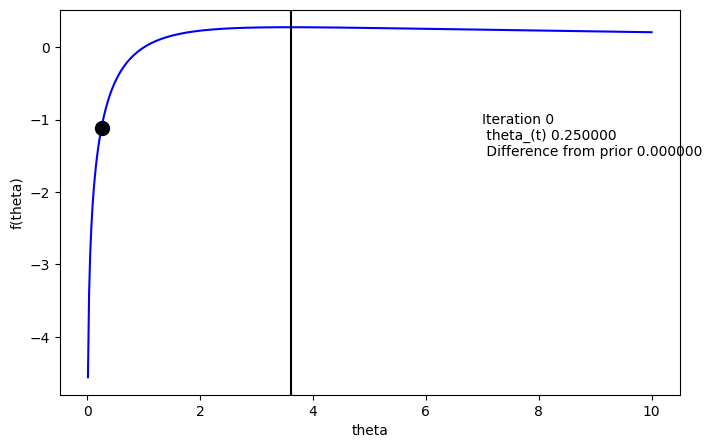

In [24]:
# Newton-Raphson animation for f(theta) = log(theta) / (1 + theta)
# starting at theta = 0.25

theta_plot = np.linspace(0.01, 10, 500)

def nr_update(th):
    """NR step for f(theta) = log(theta)/(1+theta)"""
    return ((th + 1) * (1 + 1/th - np.log(th))) / (3 + 4/th + 1/th**2 - 2*np.log(th))

fig, ax = plt.subplots(figsize=(8, 5))

th_vals = [0.25]
h_vals = [0.0]
for i in range(12):
    h = nr_update(th_vals[-1])
    th_vals.append(th_vals[-1] + h)
    h_vals.append(h)

def animate(frame):
    ax.clear()
    ax.plot(theta_plot, f1(theta_plot), 'b-')
    ax.axvline(3.6, color='black')
    ax.plot(th_vals[frame], f1(th_vals[frame]), 'ko', markersize=10)
    ax.text(7, -1.5,
            f"Iteration {frame}\n theta_(t) {th_vals[frame]:.6f}\n Difference from prior {h_vals[frame]:.6f}",
            fontsize=10)
    ax.set_ylabel("f(theta)")
    ax.set_xlabel("theta")

anim = FuncAnimation(fig, animate, frames=len(th_vals), interval=800, repeat=False)
HTML(anim.to_jshtml())

You can see that the algorithm appears to **converge** in approximately 12 iterations to about 3.59112 (the value of $\theta$ pertaining to the true maximum of the $f(\theta)$), where the difference between the value of $\hat{\theta}$ at the 11th step ($\hat{\theta}^{(11)}$) and the 12th step ($\hat{\theta}^{(12)}$) is very small.

#### Criteria for convergence: absolute versus relative
If we define our **tolerance** for convergence, or convergence threshold, at step $t$ as some small fixed value $\epsilon$,  we may formally terminate the algorithm when $|\hat{\theta}^{(t)} - \hat{\theta}^{(t-1)}| < \epsilon$.  Here, the optimal value of $\theta$  is $\theta^* \approx 3.59112$.

Clearly, larger values of $\epsilon$ will result in convergence in fewer iterations, however the resulting $\hat{\theta}$ may be less accurate (further aware from $\theta^*$).  Depending on the application, a higher or lower convergence threshold may be warranted, where in some cases 10 decimal places of accuracy (and potentially requiring many more iterations for meeting the convergence threshold) may not be necessary.

Other criteria for determining convergence exist.  You may notice from the definition above that the algorithm converges if the raw difference in $\theta^{(t+1)}$ and $\theta^{(t)}$ becomes small.  However, if  $\theta^*$  is generally large in scale (say, typically > 10000 in value), an $\epsilon$ of $10^{-6}$ may be too restrictive or difficult to reach, whereas if $\theta^*$ is in the range of $10^{-12}-10^{-16}$, an of $\epsilon$ of $10^{-6}$ may simply be too liberal.  All in all, the threshold's stringency may depend on the scale of $\theta^*$.

For these reasons some may prefer a **relative** convergence threshold, such as $\frac{|\theta^{(t+1)} - \theta^{(t)}|}{|\theta^{(t)}|} < \epsilon$, where convergence is now met if the change relative to $\theta^{(t)}$ is smaller than some proportion $\epsilon$. For example we may instead want to terminate the algorithm when the change is less than say $1\%$ of the previous value, rather than specifying an exact value of the difference.   However, relative convergence criteria can become problematic if $\theta^{(t)}$ or $\theta^*$ is very close to zero. In that case, an alternative criterion $\frac{|\theta^{(t+1)} - \theta^{(t)}|}{|\theta^{(t)}| + \epsilon} < \epsilon$ may help prevent instability in the criterion.

It is also helpful to add a **maximum iteration limit** to prevent runaway divergence or to halt poorly converging algorithms (sometimes indicative of bad starting points).  This limit may also be reached if your convergence threshold is too stringent, and/or the iteration limit is too low.  Printing a warning message when this limit is reached is common among algorithms.

#### Impact of starting values on convergence
Lets now examine the impact of a different starting point for the algorithm, $\theta^{(0)} = 1$.

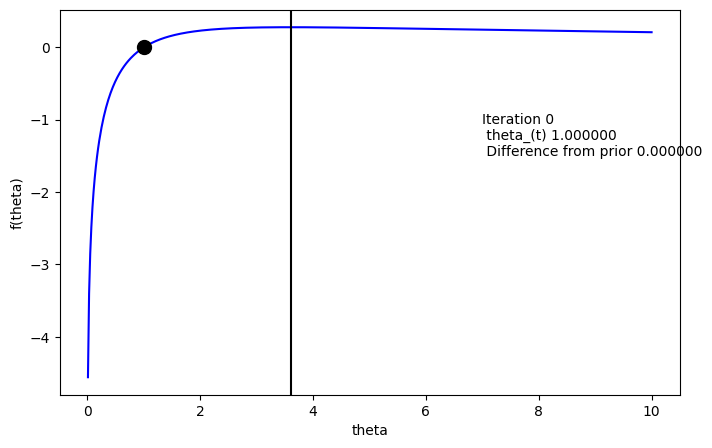

In [25]:
# Newton-Raphson animation starting at theta = 1

fig, ax = plt.subplots(figsize=(8, 5))

th_vals = [1.0]
h_vals = [0.0]
for i in range(12):
    h = nr_update(th_vals[-1])
    th_vals.append(th_vals[-1] + h)
    h_vals.append(h)

def animate(frame):
    ax.clear()
    ax.plot(theta_plot, f1(theta_plot), 'b-')
    ax.axvline(3.6, color='black')
    ax.plot(th_vals[frame], f1(th_vals[frame]), 'ko', markersize=10)
    ax.text(7, -1.5,
            f"Iteration {frame}\n theta_(t) {th_vals[frame]:.6f}\n Difference from prior {h_vals[frame]:.6f}",
            fontsize=10)
    ax.set_ylabel("f(theta)")
    ax.set_xlabel("theta")

anim = FuncAnimation(fig, animate, frames=len(th_vals), interval=800, repeat=False)
HTML(anim.to_jshtml())

Now lets lets try $\theta^{(0)} = 4$.

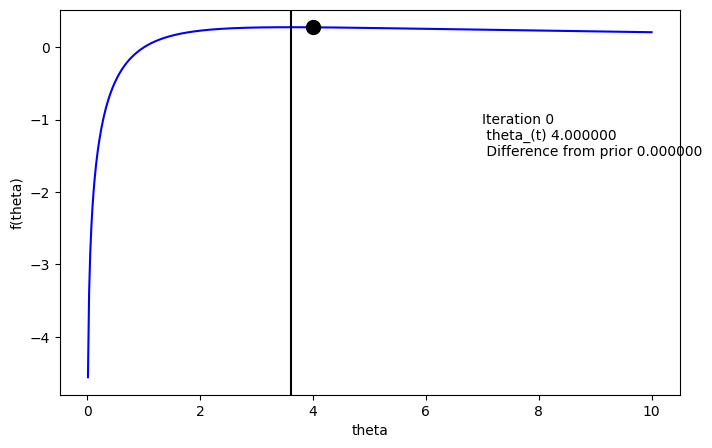

In [26]:
# Newton-Raphson animation starting at theta = 4

fig, ax = plt.subplots(figsize=(8, 5))

th_vals = [4.0]
h_vals = [0.0]
for i in range(12):
    h = nr_update(th_vals[-1])
    th_vals.append(th_vals[-1] + h)
    h_vals.append(h)

def animate(frame):
    ax.clear()
    ax.plot(theta_plot, f1(theta_plot), 'b-')
    ax.axvline(3.6, color='black')
    ax.plot(th_vals[frame], f1(th_vals[frame]), 'ko', markersize=10)
    ax.text(7, -1.5,
            f"Iteration {frame}\n theta_(t) {th_vals[frame]:.6f}\n Difference from prior {h_vals[frame]:.6f}",
            fontsize=10)
    ax.set_ylabel("f(theta)")
    ax.set_xlabel("theta")

anim = FuncAnimation(fig, animate, frames=len(th_vals), interval=800, repeat=False)
HTML(anim.to_jshtml())

Now lets try something further away, $\theta^{(0)} = 8$.

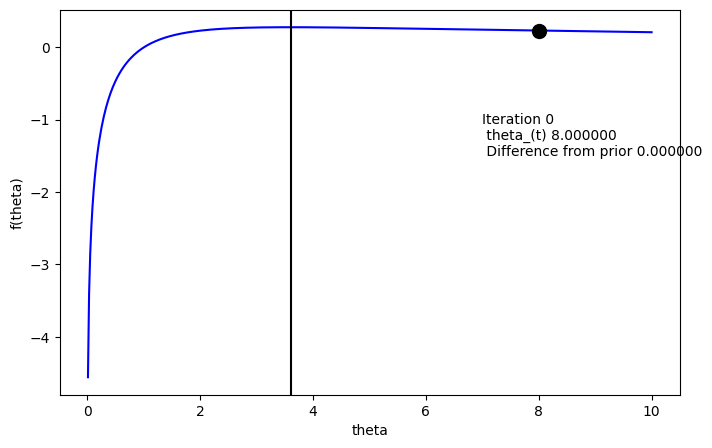

In [27]:
# Newton-Raphson animation starting at theta = 8

fig, ax = plt.subplots(figsize=(8, 5))

th_vals = [8.0]
h_vals = [0.0]
for i in range(12):
    h = nr_update(th_vals[-1])
    th_vals.append(th_vals[-1] + h)
    h_vals.append(h)

def animate(frame):
    ax.clear()
    ax.plot(theta_plot, f1(theta_plot), 'b-')
    ax.axvline(3.6, color='black')
    ax.plot(th_vals[frame], f1(th_vals[frame]), 'ko', markersize=10)
    ax.text(7, -1.5,
            f"Iteration {frame}\n theta_(t) {th_vals[frame]:.6f}\n Difference from prior {h_vals[frame]:.6f}",
            fontsize=10)
    ax.set_ylabel("f(theta)")
    ax.set_xlabel("theta")

anim = FuncAnimation(fig, animate, frames=len(th_vals), interval=800, repeat=False)
HTML(anim.to_jshtml())

In some cases, the end result of the algorithm is the same regardless of the chosen starting point of the algorithm, however fewer iterations may be required for $\theta^{(t)} \rightarrow \theta^*$ (due to a better starting point).  In other cases, you can see that the model may converge to a value other than $\theta^*$, representing a **local optimum** rather than the **global optimum**.   Or, the algorithm may not converge at all (diverges), as in the last example above. Starting at $\theta^{(0)} = 8$, the algorithm diverges because $\theta = 8$ lies past an **inflection point** of $f(\theta)$ (at $\theta \approx 6.25$), where $f''(\theta)$ changes sign from negative to positive. In this region, $f'(\theta) < 0$ (we are past the maximum) and $f''(\theta) > 0$ (the function is convex). The NR step $h = -f'/f''$ is therefore positive, pushing $\theta$ further to the right. Each subsequent iterate remains in this convex region with the same sign conditions, so the updates are always positive and the iterates diverge monotonically to $+\infty$.

In general, utilizing a starting value closer to $\theta^*$ results in convergence in fewer iterations.  This illustrates the importance of choosing an informative starting point for the algorithm, and there are several strategies to do this and can vary by application.

Evaluating several starting points (perhaps chosen randomly) and choosing the starting point the ends in the best value of the objective function is the best way to avoid getting trapped in a local optimum or hitting convergence failures. Other strategies include graphing/plotting, preliminary estimates (based off simpler models, or methods-of-moments estimates), educated guesses, or...trial and error.

#### Basics of Numerical Optimization Summary
To summarize, the following concepts are important for understanding the set of optimization algorithms covered in the rest of this module:

1. Algorithm starting point or initialization
2. Choice of updating algorithm
3. Specification of stopping criteria

In the next few sections we will go into detail regarding various approaches for numerical optimization and their pros and cons for use. We will also discuss algorithm-specific aspects of computational complexity and convergence speed of each approach to help you decide which algorithm may be better to utilize for your specific application.

### Newton-Raphson
In the previous illustration we used a common technique called **Newton-Raphson** (NR) to optimize the function of interest with respect to $\theta$. This approach is also referred to as Newton's Method, and is an iterative updating scheme to arrive at $\hat{\theta}$.

One notable requirement of this method is that expressions for  the **first and second derivatives of the function of interest must be given**.  In some situations such derivatives may be difficult to derive or evaluate in practice. We will introduce several alternative numerical optimization procedures to handle these situations later in this lecture.

Let $\theta^{(0)}$ denote the starting value for the estimate of $\theta$ and assume that we wish to maximize some function $f(\theta)$.  Then, based on this scheme, we update our estimate of $\theta$ at the $t$th step of the algorithm ($\theta^{(t)}$) using the following expression: $$\theta^{(t+1)} = \theta^{(t)} + h^{(t)},$$ where $h^{(t)} = -\frac{f'(\theta^{(t)})}{f''(\theta^{(t)})},$ $f'(\theta)$ is the first derivative of $f(\theta)$ with respect to $\theta$ evaluated at $\theta^{(t)}$, and $f''(\theta)$ is the second derivative of $f(\theta)$ with respect to $\theta$ evaluated at $\theta^{(t)}$.

If we sought to instead minimize $f(\theta)$, the same update would apply.  After choosing an appropriate starting point for the algorithm and stopping rule, we can apply the updating rule above as we had in the previous example to arrive at $\hat{\theta}$.

A few obvious questions:

1.  How did we get this expression?
2.  Why would we even expect $\theta^{(t)} \rightarrow \theta^*$?
3.  Under what conditions do we expect the algorithm to work well or not work well?
4.  How quickly would we expect $\theta^{(t)} \rightarrow \theta^*$ in $t$?

There may be situations where the algorithm may not converge or do so in a suitable timeframe.  Understanding the rationale behind this approach and its properties may help navigate these situation may provide clues to what alternative approaches may work.

#### Rationale and Derivation
Let us suppose that $f'(\theta)$ is continually differentiable, $f''(\theta)$ exists, and that $f''(\theta) \neq 0$ (suggesting that the first derivative is non-constant).  At a given iteration $t$, $f'(\theta^*)$ can be approximated by a linear Taylor Series Expansion about $\theta^*$, the unknown true value of $\theta$ that maximized $f(\theta)$.  Yes, we do not know what $\theta^*$ is in reality, but this term is important when we talk about the conditions that may impact the performance of this approach later on.

Under this approximation, we have $$0 = f'(\theta^*)  \approx f'(\theta^{(t)}) + (\theta^* - \theta^{(t)})f''(\theta^{(t)}).$$  Lets unpack what this means for one second.  If you recall, most analytic approaches to optimizing algorithms start with setting the **1st derivative to 0** and solving for the value of $\theta$ satisfying this equality.  In this setting, we assume that such an analytic solution does not exist.  Therefore, we approximate this derivative using this **linear** Taylor Series approximation around $\theta^*$, and then set **this** approximation to zero.  Here, $f'(\theta^*)$ is approximated by the tangent line at $\theta^{(t)}$ (see figure below).

![*Example of Newton Raphson in the context of the previous illustration.  The algorithm approximates $g'$ by its tangent line at $\theta^{(t)}$, whose root $\theta^{(t+1)}$ serves as the next approximation of the true root $\theta^{*}$.*](chap2figgoodnewt.jpg){width=65%}

Since we are approximating $f'(\theta^*)$ with  its **tangent line** at $\theta^{(t)}$, it makes sense that we can approximate the root of $f'(\theta^*)$ (the point at which it equals 0) with **the root of the tangent line** at  $\theta^{(t)}$.  Under this rationale, we solve for $\theta^{(*)}$ in the linear Taylor Series approximation above.  Doing this, we have $$\theta^*  = \theta^{(t)} - \frac{f'(\theta^{(t)})}{f''(\theta^{(t)})} = \theta^{(t)} + h^{(t)}.$$  In other words, the value for $\theta^*$ at iteration $t$ is approximated using the current guess $\theta^{(t)}$ and a refinement step $h^{(t)}$.   Successive iterations of this approach will yield closer and closer approximations to $\theta^*$.

#### Updating Equation
Using the above rationale, we can define the updating strategy as  $$\theta^{(t+1)}  = \theta^{(t)} - \frac{f'(\theta^{(t)})}{f''(\theta^{(t)})} = \theta^{(t)} + h^{(t)}.$$

When the optimization of $f$ corresponds to maximum likelihood estimation, where $\hat{\theta}$ is the solution to $l'(\theta) = 0$, the updating equation is given as $$\theta^{(t+1)}  = \theta^{(t)} - \frac{l'(\theta^{(t)})}{l''(\theta^{(t)})}.$$

#### Requirements and Convergence
But how do we know that successive iterations using the updating equation above will result in convergence to $\theta^*$, rather than diverging or converging to some other value?  In practice, this depends on the shape of the function you are maximizing as well as your chosen starting value.

As we can see from the prior examples, choosing starting values too far away from $\theta^*$ results in slower convergence or even divergence.  Choosing values closer to the $\theta^*$ results in quicker convergence.

We can show that if $f'''(\theta)$ is continuous and that $\theta^*$ is a simple root of $f'(\theta)$ (implying that $f'(\theta^*) = 0$), then there exists a *neighborhood* around $\theta^*$ for which NR converges to $\theta^*$ from any starting value $\theta^{(0)}$ within that neighborhood (GH 2.1.1, eq. 2.18).  The definition of "neighborhood" in this sense is somewhat arbitrary, but is meant to indicate that convergence is likely if you are in some close vicinity of $\theta^*$.  GH provides this proof using arguments based upon the error of a quadratic Taylor Series approximation for $f'(\theta)$ in Section 2.1.1.

More specifically, if $f'(\theta)$ is twice differentiable, is convex, and has a root, then NR will converge from any point!  These conditions are typically met by common likelihood functions in statistics (but not always).

If you are starting in some arbitrary interval $[a,b]$, you can check the following conditions to determine whether the NR algorithm will converge from any $\theta^{(0)}$ in that interval:

1.  $f''(\theta) \neq 0$ on $[a,b]$
2.  $f'''(\theta)$ does not change sign on $[a,b]$
3.  $f'(a)f'(b) < 0$, and
4.  $|f'(a)/f''(a)| < b-a$ and $|f'(b)/f''(b)| < b-a$

These statements follow from the proof given in GH 2.1.1.  In practice most do not manually evaluate these statements  before applying NR, but in cases where problems arise, can help explain problems relating to convergence if observed.  Rephrased, we can translate these conditions into the following:

1.  The 2nd derivative is never equal to zero in the interval $\rightarrow$ $f'(\theta)$ is never flat on $[a,b]$ $\rightarrow$ $f'(\theta)$ can potentially intersect 0 in the interval $\rightarrow$ $f'(\theta)$ has the potential to have a root in $[a,b]$
2.  The third derivative does not change sign on $[a,b]$ $\rightarrow$ the sign of the second derivative stays the same in the interval on $[a,b]$ $\rightarrow$ no change in convexity/concavity in interval
3.  Implies that the 1st derivative at $a$ is positive and negative at $b$ (or vice versa) $\rightarrow$ $f'(\theta)$ changes sign at some point in $[a,b]$ $\rightarrow$ implies a root for $f'(\theta)$ must exist in $[a,b]$
4.  The absolute value of $h$ at $a$ or at $b$ is less than the length of the interval $\rightarrow$ the step size (refinement) assuming $\theta^{(0)} = a$ or $\theta^{(0)} = b$ is smaller than the length of the interval being considered.  If this is not true, the update will definitely not be contained in $[a,b]$.

Using similar arguments, we can show that the convergence order for NR is *quadratic*, meaning the accuracy of the solution will double with each iteration $t$.   Higher convergence order implies that accurate approximations for the parameter(s) of interest are achieved in fewer iterations.

However, we will see that algorithms with higher convergence orders may also be less robust to different conditions and may fail more frequently than slower algorithms.  For example, NR is relatively more sensitive to the starting value compared to other methods.

#### Pros and Cons
* Pros
    + Speed:  Extremely Fast convergence
* Cons
    + Requires derivation and evaluation of 1st and 2nd derivatives
    + Relatively more sensitive to the choice of starting value
    + In the multivariate setting, need checks on the hessian to avoid singularities, other issues

If the derivatives and/or likelihood are complicated, NR may not be an attractive choice. In addition, if the derivatives required additional work for evaluation (such as likelihoods involving integration), performing additional evaluations in the 1st and 2nd derivatives may similarly be unattractive. With respect to NR, John Nash in "Nonlinear parameter optimization using R tools" summarizes

> There are lots of dangerous beasts in the night-time optimization forest.

The apparent difficulties with NR in the multivariate setting is why it was not included as a method in `scipy.optimize.minimize`, which instead favors methods like BFGS.

#### Example of NR applied to the simpler Poisson problem

Lets determine the 1st and 2nd derivatives of the simple Poisson example from earlier.  This is the same approach that we will will apply to the Poisson Regression example but will be left for a later section.  Here $\mathcal{l}'(\lambda) = -n + \left(\sum_{i = 1}^{n} y_i \right)/\lambda$ and the second derivative is $\mathcal{l}''(\lambda) = -\left(\sum_{i = 1}^{n} y_i \right)/\lambda^2$.

Now, lets generate some data and apply NR:

In [28]:
# generate 100 poisson(10) samples
np.random.seed(10)
n = 100
lam_true = 10
y = np.random.poisson(lam_true, n)
print(np.mean(y))

9.61


Now lets get our functions in order

In [29]:
# log likelihood function
def logLik(lam, y):
    return np.sum(stats.poisson.logpmf(y, lam))

# lets write a function for the first derivative
def d1(lam, y):
    return -len(y) + np.sum(y) / lam

# now the second
def d2(lam, y):
    return -np.sum(y) / lam ** 2

Now lets apply NR.  We pick a tolerance level (**tol**) and starting value (**lam**).  Here the choice of starting value is arbitrary. We can vary this to see its impact on the final value later.   It's also helpful to specify a maximum number of iterations (**maxit**) to halt the algorithm so it does not loop infinitely if there is a convergence issue.  We can also add conditions to check whether $\lambda^{(t)} > 0$.

In [30]:
# now lets apply NR. First lets set the tolerance and choose a starting value
# the start
tol = 10**-4
lam = 0.1
maxit = 50
iteration = 0  # iteration counter
eps = np.inf  # keeps track of current difference
start = time.time()  # record start time

while eps > tol and iteration < maxit:
    # save the previous value
    lam0 = lam

    # calculate h, the increment
    h = -d1(lam, y) / d2(lam, y)

    # update lambda
    lam = lam + h

    # update the log likelihood
    logL = logLik(lam, y)

    # calculate the diff in lambda, could also use the log likelihood if we wanted
    eps = abs(lam - lam0)

    # update the iteration number
    iteration += 1
    if iteration == maxit:
        print("Warning: Iteration limit reached without convergence")

    # print out info to keep track
    print(f"Iter: {iteration} logL: {logL:.6f} lam: {lam:.6f} h: {h:.6f} eps:{eps:.6f}")

end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")

Iter: 1 logL: -3032.350766 lam: 0.198959 h: 0.098959 eps:0.098959
Iter: 2 logL: -2395.720172 lam: 0.393800 h: 0.194840 eps:0.194840
Iter: 3 logL: -1787.266483 lam: 0.771462 h: 0.377663 eps:0.377663
Iter: 4 logL: -1231.473801 lam: 1.480994 h: 0.709532 eps:0.709532
Iter: 5 logL: -767.693410 lam: 2.733752 h: 1.252758 eps:1.252758
Iter: 6 logL: -444.628528 lam: 4.689835 h: 1.956083 eps:1.956083
Iter: 7 logL: -287.441392 lam: 7.090955 h: 2.401120 eps:2.401120
Iter: 8 logL: -249.595186 lam: 8.949689 h: 1.858734 eps:1.858734
Iter: 9 logL: -247.227823 lam: 9.564629 h: 0.614940 eps:0.614940
Iter: 10 logL: -247.217080 lam: 9.609786 h: 0.045156 eps:0.045156
Iter: 11 logL: -247.217079 lam: 9.610000 h: 0.000214 eps:0.000214
Iter: 12 logL: -247.217079 lam: 9.610000 h: 0.000000 eps:0.000000
Time elapsed: 0.001627 seconds


We can also visualize this below


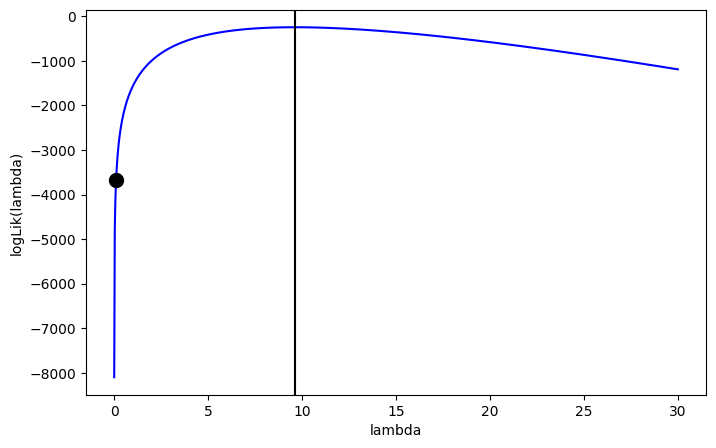

In [31]:
# Animated NR for Poisson log-likelihood

tol = 10**-4
lam = 0.1
maxit = 50
eps = np.inf

lam_range = np.linspace(0.001, 30, 1000)
loglik_vals = np.array([logLik(l, y) for l in lam_range])

lam_history = [lam]
while eps > tol and len(lam_history) <= maxit:
    lam0 = lam
    h = -d1(lam, y) / d2(lam, y)
    lam = lam + h
    eps = abs(lam - lam0)
    lam_history.append(lam)

fig, ax = plt.subplots(figsize=(8, 5))

def animate(frame):
    ax.clear()
    ax.plot(lam_range, loglik_vals, 'b-')
    ax.axvline(np.mean(y), color='black')
    current_lam = lam_history[frame]
    ax.plot(current_lam, logLik(current_lam, y), 'ko', markersize=10)
    ax.set_ylabel("logLik(lambda)")
    ax.set_xlabel("lambda")

anim = FuncAnimation(fig, animate, frames=len(lam_history), interval=800, repeat=False)
HTML(anim.to_jshtml())

### Fisher Scoring
Fisher Scoring is an alternative to NR when performing maximum likelihood estimation, where we simply replace $l''(\theta^{(t)})$ with $I(\theta^{(t)})$, the expected Fisher Information matrix at iteration $t$. The expected Fisher Information is defined as $$I(\theta) = E[-l''(\theta)] = E[l'(\theta)^2],$$ where the expectation is taken over the distribution of the data. Intuitively, $I(\theta)$ measures the amount of information the data carry about $\theta$: when $I(\theta)$ is large, the log-likelihood is sharply curved and the data are highly informative about $\theta$.  We can show that $-l''(\theta)$, also known as the **observed Fisher Information**, is an approximation for $I(\theta)$ (GH 1.4), so it is not surprising that the asymptotic properties for NR and FS are similar.

The updating equation is given as $$\theta^{(t+1)}  = \theta^{(t)} + I(\theta^{(t)})^{-1}l'(\theta^{(t)}).$$ Given the particular problem at hand, NR or FS may be easier to derive analytically, where the latter only needs knowledge of the **1st derivatives** and avoids computation of the 2nd derivatives. According to GH, FS may be used in early iterations for rapid improvements, and NR can be used to make better refinements near the end. Note that $I(\theta)^{-1}$ acts as a scaling factor for the gradient $l'(\theta)$: in the univariate case, the update $\theta^{(t+1)} = \theta^{(t)} + l'(\theta^{(t)})/I(\theta^{(t)})$ scales the gradient by the inverse of the expected information. Compare this with gradient descent (or gradient ascent for maximization), where the update is $\theta^{(t+1)} = \theta^{(t)} + \alpha \cdot l'(\theta^{(t)})$ for a fixed step size $\alpha$. Fisher Scoring effectively replaces the fixed step size with an adaptive one, $1/I(\theta^{(t)})$, that accounts for the curvature of the log-likelihood. When $I(\theta)$ is large (the log-likelihood is sharply curved), the step is smaller, and when $I(\theta)$ is small (the log-likelihood is flat), the step is larger.

* Pros
    + Avoids derivation and computation of the 2nd derivative
    + Similar asymptotic properties of NR
    + In the multivariate setting, may be more stable than NR (will talk about this later)
    + Works better in the beginning to make rapid improvements
* Cons
    + May not be as fast for refinement near end

### Secant Method
This approach is similar to NR, except that the second derivative in the updating equation is replaced with a finite-difference approximation, where now the updating equation is $$\theta^{(t+1)}  = \theta^{(t)} - f'(\theta^{(t)})\frac{\theta^{(t)} - \theta^{(t-1)}}{f'(\theta^{(t)}) - f'(\theta^{(t-1)})}.$$ Conditions for convergence are similar to NR, but we can show through similar arguments that the convergence order for the secant method is 1.62 instead of 2. The **convergence order** $p$ of an iterative method describes how quickly the error decreases: if the error at step $t$ is $e_t = |\theta^{(t)} - \theta^*|$, then a method with convergence order $p$ satisfies $e_{t+1} \leq C \cdot e_t^p$ for some constant $C$. NR has order $p=2$ (quadratic convergence), meaning the number of correct digits roughly doubles each iteration. The secant method has order $p = (1+\sqrt{5})/2 \approx 1.62$ (superlinear convergence), which is slower than quadratic but still faster than linear convergence ($p=1$).  To initialize this approach, two starting values have to be provided.  Typically the first value is picked in a manner not dissimilar to the other approaches described in this lecture, and the second value is picked relatively close to the first one.  Then we may compute the first update and proposal for $\theta^{(1)}$ and start the algorithm.

* Pros
    + Avoids derivation and computation of the 2nd derivative
    + Similar asymptotic properties of NR
* Cons
    + Slower convergence relative to NR

### Examples

Lets apply FS to our simple Poisson problem.  To do this, lets first calculate the expected information $I(\theta)$, which is $I(\theta) = E[l'(\theta)^2] = E[-l''(\theta)]$ in the univariate setting.  This expression can be calculated by brute force using the following

$$
\begin{align}
E[l'(\theta)^2] &=E\left[\left(-n + \left(\sum_{i = 1}^{n} y_i \right)/\lambda\right)^2\right]\\
&=E\left[\left(\sum_{i = 1}^{n} y_i \right)^2/\lambda^2 - 2n\left(\sum_{i = 1}^{n} y_i \right)/\lambda + n^2\right]\\
&= E\left[\left(\sum_{i = 1}^{n} y_i \right)^2\right]/\lambda^2 - 2n\left(\sum_{i = 1}^{n} E[y_i] \right)/\lambda + n^2\\
&= (n\lambda + (n\lambda)^2)/\lambda^2 - 2n\left(\sum_{i = 1}^{n} \lambda \right)/\lambda + n^2\\
&= n/\lambda + n^2 - 2n^2 + n^2\\
&= n/\lambda  \\
\end{align}
$$

We can see this has a nice form and avoids having to analytically determine a second derivative.

In [32]:
# now lets apply FS using same framework as before
# the start
tol = 10 ** -4
lam = 0.1
maxit = 50
iteration = 0
eps = np.inf

start = time.time()
while eps > tol and iteration < maxit:
    # save the previous value
    lam0 = lam

    # calculate h, the increment.
    h = d1(lam, y) / (n / lam)

    # update lambda
    lam = lam + h

    # lambda cant be less than or equal to 0, so put a check for this
    if lam <= 0:
        raise ValueError("lambda leq 0")

    # update the log likelihood
    logL = logLik(lam, y)

    # calculate the diff, could also use the log likelihood if we wanted
    eps = abs(lam - lam0)

    # update the iteration number
    iteration += 1
    if iteration == maxit:
        print("Warning: Iteration limit reached without convergence")

    # print out info to keep track
    print(f"Iter: {iteration} logL: {logL:.6f} lam: {lam:.6f} h: {h:.6f} eps:{eps:.6f}")

end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")

Iter: 1 logL: -247.217079 lam: 9.610000 h: 9.510000 eps:9.510000
Iter: 2 logL: -247.217079 lam: 9.610000 h: 0.000000 eps:0.000000
Time elapsed: 0.000322 seconds


## Multivariate Optimization

The approaches that we have described also extend to the multivariate setting, where we seek to optimize a function with respect to more than one parameter at the same time.  More formally, we see to find the optimum of some real valued function $f(\boldsymbol{\theta})$, where $\boldsymbol{\theta}$ is now some $p$-dimensional vector of parameters such that $\boldsymbol{\theta} = (\theta_1,\ldots,\theta_p)^T$.  Similar to before, the estimate of $\boldsymbol{\theta}$ at step $t$ will be denoted as $\boldsymbol{\theta}^{(t)}$.  Most of the prior concepts covered in univariate maximization, such as regarding starting points, iterative updating, and specification of convergence criteria for termination, also applies here.

### Note about convergence in the multivariate setting

Obviously in the multivariate setting we cannot directly utilize the same convergence criteria defined earlier.  To extend this to the multivariate setting, we may use distance-based measures for convergence, for example based one the sum of the absolute differences between iterations $$D(\mathbf{u},\mathbf{v}) = \sum_{i=1}^p | u_i - v_i|$$ or the Euclidean distance between iterations $$D(\mathbf{u},\mathbf{v}) = \sqrt{\left(\sum_{i=1}^p (u_i - v_i)^2\right)}.$$  The output of these functions are scalars, so given a particular choice of $D(\mathbf{u},\mathbf{v})$, we can define a particular absolute convergence threshold $\epsilon$ to terminate the algorithm such that $D(\boldsymbol{\theta}^{(t+1)},\boldsymbol{\theta}^{(t)}) < \epsilon$.  We can similarly define a relative convergence threshold $\epsilon$ such that $$\frac{D(\boldsymbol{\theta}^{(t+1)},\boldsymbol{\theta}^{(t)})}{D(\boldsymbol{\theta}^{(t)},0)} < \epsilon$$.

As before, we may also decide to use the value of **the objective function itself** as the basis for our criterion for convergence (the estimated likelihood at iteration $t$ for example).  In some cases, particularly when the dimension of the parameter space is high, this approach may be simpler to utilize.

We will now discuss multivariate extensions to the methods introduced in the previous section.

###  Newton-Raphson and Fisher Scoring

Using the rationale described in the univariate setting, we can define the NR updating algorithm in this setting using a quadratic Taylor Series expansion around $f(\boldsymbol{\theta}^*)$:  $$f(\boldsymbol{\theta}^*) = f(\boldsymbol{\theta}^{(t)}) + (\boldsymbol{\theta}^* - \boldsymbol{\theta}^{(t)})^T f'(\theta^{(t)}) + \frac{1}{2}(\boldsymbol{\theta}^* - \boldsymbol{\theta}^{(t)})^T f''(\theta^{(t)})(\boldsymbol{\theta}^* - \boldsymbol{\theta}^{(t)}).$$ If we take the derivative of this expansion and set it equal to zero, we get $$0 = f'(\boldsymbol{\theta}^{(t)}) + f''(\boldsymbol{\theta}^{(t)})(\boldsymbol{\theta}^* - \boldsymbol{\theta}^{(t)}),$$  which provides the update $$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - f''(\boldsymbol{\theta}^{(t)})^{-1}f'(\boldsymbol{\theta}^{(t)}).$$

As a side note, if you recall, in our derivation from the univariate setting we started with a linear Taylor Series expansion of $f'(\theta^*)$.  Doing the same here would allow us to arrive at the same expression given above (here we take the derivative of the expansion around $f(\theta^*)$).  So, our increment $\mathbf{h}^{(t)}$ is simply  $\mathbf{h}^{(t)} = -f''(\boldsymbol{\theta}^{(t)})^{-1}f'(\boldsymbol{\theta}^{(t)})$.

**Fisher scoring** in this case also has a similar updating function $$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} + \mathbf{I}(\boldsymbol{\theta}^{(t)})^{-1}\mathbf{l}'(\boldsymbol{\theta}^{(t)}).$$  The properties of these algorithms will be similar to those described in the univariate section.

We will illustrate these multivariate results with an example in the next section.

#### GLMs: NR, FS, and IRLS
Generalized Linear Models (GLMs) encompass a large family of models including linear regression, logistic regression (binary responses), Poisson regression (count responses), and many others.  In contrast to linear regression, the class of models encompassed by GLMs can handle response variables of different distributions, where such distributions are members of what we call the "exponential family" of distributions.

The exponential family has the general form $$f(y; \theta,\phi) = \exp\left[(y\theta-b(\theta)]/a(\phi)) + c(y,\phi)\right],$$ where $\theta$ is called the "natural" or "canonical" parameter and $\phi$ is a fixed dispersion parameter.  The following distributions can be factored into this form, and therefore belong to the exponential family:

* Bernoulli
* Poisson
* Normal
* Exponential
* Gamma
* Chi-Squared
* Beta
* Dirichlet
* Wishart
* Geometric
* Binomial (fixed number of trials)
* Negative Binomial (fixed number of failures or fixed overdispersion parameter)
* Multinomial (fixed number of trials)

Note that the last three distributions have conditional membership to this family of distributions, which in some cases impacts how likelihood functions based on these distributions are maximized (an example of this will be given later).

For these distributions, we  can factor their densities into the form above to determine $b(\theta)$, $a(\phi)$, and $c(y,\phi)$.  We can then utilize these quantities to estimate the parameters of interest in our model in a general unified framework.  For example, we can show that $E[Y] = b'(\theta)$ and $var[Y] = b''(\theta)a(\phi)$.

Similar to linear regression, we often wish to model $Y_i$ with respect to some vector of covariates $\mathbf{X}_i$, the $i$th row of an $n \times p$ matrix of covariates $\mathbf{X}$.  Let us define $\mu_i =E[Y_i |\mathbf{X}_i]$.  In this particular model, we assume that the relationship between $\mathbf{X}_i$ and $\mu_i$ are related such that $g(\mu_i) = \mathbf{X}_i\boldsymbol{\beta} = \eta_i$, where $g$ is called the "link function", $\boldsymbol{\beta}$ is a vector of unknown parameters to be estimated, and $\eta_i$ is called the "linear predictor".  The inverse link function, $g^{-1}(\eta_i) = \mu_i$, can be used to back-transform the linear predictor for subject $i$ to obtain $\mu_i$.  That is, we can model some function of $E[Y_i |\mathbf{X}_i]$ with a set of regression coefficients, where this function is the selected link function $g$.

For example, in linear regression $g$ is simply the "identity link" where $E[Y_i |\mathbf{X}_i] =\mu_i =  \mathbf{X}_i\boldsymbol{\beta}$, and no transformation is performed.  For each member of the exponential family, different link functions may be utilized, although some may be more mathematically convenient to use than others, as we will see.

In general, if we find that $b'(\theta_i) = g^{-1}(\theta_i)$, then this implies that $\theta_i = \eta_i$ and that $g(\cdot)$ is the "canonical" link function, an example of such a mathematically convenient link function.   If this is new to you, dont worry we will walk through an example of this in a bit.

Given the wide range of distributions that may be covered by the exponential family, a general estimation framework to obtain $\hat{\boldsymbol{\beta}}$ may be advantageous for modeling, as separate algorithms for different distributions can be avoided.  You will learn more about these models and various link functions in Bios 762.

##### Logistic Regression Example
If we take the example of logistic regression, we assume that the response variable $Y_i$ is distributed Bernoulli with parameter $\pi_i$, where $E[Y_i |\mathbf{x}_i] = \mu_i = \pi_i$ and $i =  1,\ldots,n$.  We wish to model the probability of success for each individual $i$, $\pi_i$,  with respect to an $1 \times p$ vector of predictors $\mathbf{X}_i$ and a set of unknown regression coefficients $\boldsymbol{\beta}$, a $p\times 1$ vector. The log likelihood can be written as $$\mathcal{l}(\pi_i) = \sum_{i=1}^n y_i\log\left(\frac{\pi_i}{1-\pi_i}\right) + \log(1-\pi_i).$$

Since this distribution is part of the exponential family, we can factor the PDF into exponential family form such that the natural parameter is $\theta_i = \log(\frac{\pi_i}{1-\pi_i})$, $a(\phi) = 1$, and $b(\theta_i) = \log(1+\exp(\theta_i))$.  If we choose $g(\mu_i) = \log(\frac{\pi_i}{1-\pi_i})$, we can show that this link function, often called the logit function, is also the "canonical" link function: $$b'(\theta_i) = \frac{e^{\theta_i}}{1+e^{\theta_i}} = \mu_i = g^{-1}(\theta),$$  and therefore $\theta_i = \eta_i = X_i\boldsymbol{\beta}$. We will see why this is convenient when we rewrite the likelihood below.  The inverse link function here is  $g^{-1}(\theta_i) = \frac{e^{\theta_i}}{1+e^{\theta_i}} = \mu_i$.

We can  show that the likelihood for this model can then be written in the form

$$
\begin{align}
l(\boldsymbol{\theta}) &= \sum_{i = 1}^n Y_i\theta_i - b(\theta_i) \\
&= \sum_{i = 1}^n Y_i\mathbf{X}_i\boldsymbol{\beta} - b(\theta_i) \\
&= \mathbf{Y}^T\mathbf{X}\boldsymbol{\beta} - \textbf{b}^T(\theta)\mathbf{1},
\end{align}
$$

where we can conveniently replace $\log(\frac{\pi_i}{1-\pi_i})$ in the original log likelihood with $\mathbf{X}_i\boldsymbol{\beta}$ through the use of the canonical link function.

##### NR-based approach to maximization (assuming canonical link)
Using similar logic as before to maximize the likelihood with respect to $\boldsymbol{\beta}$, let us try to find $\boldsymbol{\beta}$ such that the first derivative of the likelihood function above is equal to zero.  We can show that the first derivative of the likelihood function (also called the score function) can be written as $$\mathbf{l}'(\boldsymbol{\beta}) = \mathbf{X}^T(\mathbf{Y} - \boldsymbol{\pi}),$$ where $\boldsymbol{\pi} = (\pi_1,\ldots,\pi_n)$.  Notice that this expression is now a $p$-dimensional vector, as we are taking the derivative of the likelihood with respect to each element of $\boldsymbol{\beta}$, which is also $p$-dimensional.

The second derivative of the likelihood function (called the "Hessian") is given as $$\mathbf{l}''(\boldsymbol{\beta}) = \frac{d}{d\boldsymbol{\beta}}(\mathbf{X}^T(\mathbf{Y}-\boldsymbol{\pi})) = -\left(\frac{d\boldsymbol{\pi}}{d\boldsymbol{\beta}}\right)^T\mathbf{X} = -\mathbf{X}^T\mathbf{W}\mathbf{X},$$ where $\mathbf{W}$ is a diagonal matrix with the $i$th diagonal element having value equal to $\pi_i(1-\pi_i)$.  Note that the Hessian is a matrix.

Plugging in these values into the NR algorithm defined earlier, the updating algorithm is given as

$$
\begin{align}
\boldsymbol{\beta}^{(t+1)}& = \boldsymbol{\beta}^{(t)} - \mathbf{l}''(\boldsymbol{\beta}^{(t)})^{-1}\mathbf{l}'(\boldsymbol{\beta}^{(t)})\\
&=  \boldsymbol{\beta}^{(t)} + (\mathbf{X}^T\mathbf{W}^{(t)}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{Y} - \boldsymbol{\pi}^{(t)})\\
&= \boldsymbol{\beta}^{(t)} + \mathbf{h}^{(t)},
\end{align}
$$

where $\boldsymbol{\pi}^{(t)}$ depends on $\boldsymbol{\beta}^{(t)}$ and $\mathbf{W}$ is a function of $\boldsymbol{\pi}^{(t)}$.

Given the fact that the Hessian **does not** depend on the observed data, we can see that the expected Fisher Information Matrix is equal to the Observed information matrix, where $\mathbf{I}(\boldsymbol{\beta}) = E[-\mathbf{l}''(\boldsymbol{\beta})]  = E[\mathbf{X}^T\mathbf{W}\mathbf{X}] = -l''(\boldsymbol{\beta})$.

As a result, FS and NR for this particular example are exactly the same, and holds for the more general case when the link function is chosen as the canonical link!  However, this will not always hold in other scenarios.

##### FS and IRLS-based approach to maximization for arbitrary link functions (including non-canonical links)

Under non-canonical links, the derivatives of the likelihood function become much more complicated, and methods such as FS may be more amenable to implement in this scenario.

More generally, we can show that FS (for both canonical and non-canonical links) in this setting is similar to performing weighted least squares, where we can defined an "error" or "residual" value $$e_i^{(t)} = g'\left(\mu_i^{(t)}\right)(Y_i - \mu_i^{(t)}),$$ a "working response" value $$z_i^{(t)} = \mathbf{X}_i\boldsymbol{\beta}^{(t)} + e_i^{(t)},$$ and a weight value $$w_i^{(t)} =   \left(g'\left(\mu_i^{(t)}\right)^2b''(\theta^{(t)})\alpha(\phi^{(t)})\right)^{-1}.$$ Then, we can solve for $\boldsymbol{\beta}^{(t+1)}$ such that $$\boldsymbol{\beta}^{(t+1)} = (\mathbf{X}^T\mathbf{W}^{(t)}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}^{(t)}z^{(t)},$$ where $\mathbf{W}^{(t)} = diag(w_1^{(t)},\ldots,w_n^{(t)})$ and $z = (z_1^{(t)},\ldots,z_n^{(t)})^T$.

This result comes from again a Taylors Series expansion approximating the score function.  Looking to results from Bios 663, it is clear that this expression has a form somewhat similar to the estimate for $\hat{\boldsymbol{\beta}}$ in the standard linear model ($(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y})$, except instead of $\mathbf{y}$ we have the working response vector $\mathbf{z}$ and a weight matrix $\mathbf{W}$ involved.  This diagonal weight matrix is often found in weighted linear regression, where such weights are used to correct for non-constant variance between observations (heteroscedasticity).  Therefore, no special computation is needed to complete the update, provided that $\mathbf{W}$ and $\mathbf{z}$ are specified.

In any case, in each iteration we update the estimate of $\boldsymbol{\beta}^{(t+1)}$ given the current values of $\mathbf{e}^{(t)}$ and $\mathbf{W}^{(t)}$, then then in turn update these intermediate quantities given $\boldsymbol{\beta}^{(t+1)}$, continuing until convergence.  This update for $\boldsymbol{\beta}^{(t+1)}$ can be computed manually using matrix computation, or using existing off the shelf software/algorithms for weighted least squares.  **We call this iterative approach of applying weighted least squares as Iteratively Reweighted Least Squares (IRLS).**

The ease in the application of this algorithm to broad variety of models is one reason why we see IRLS as the standard approach for maximizing GLMs in statistical software. Its connection to weighted least squares is another reason why it is often used in tandem with penalized likelihood approaches for high dimensional variable selection, as one can apply the similar procedures used in linear models to GLMs given the framework above.

In summary, we have the following pro's and cons for using IRLS

* Pros
    + Single implementation for wide range of models belonging to the exponential family (update form of $\mathbf{W}$ and $\mathbf{e}$ and given distribution)
    + Can handle arbitrary link functions
    + Easy to extend certain methods developed for the linear model to the GLM setting (penalization, etc)
    + Can use off the shelf applications of weighted least squares to fit
* Cons
    +  Can be slow and unreliable, unless the model fits the data well

##### Example:  Poisson regression with NR
Lets generate some data from a Poisson regression model and fit it with NR

In [33]:
# 100 samples
n = 100

# create X from two normally distributed predictors, assume intercept
np.random.seed(42)
x1 = np.random.normal(size=n)
x2 = np.random.normal(size=n)
X = np.column_stack([np.ones(n), x1, x2])

# pick beta
beta = np.array([1.0, 1.0, 1.0])

# simulate samples
lam = np.exp(X @ beta)
y = np.random.poisson(lam)

Now lets plot the data

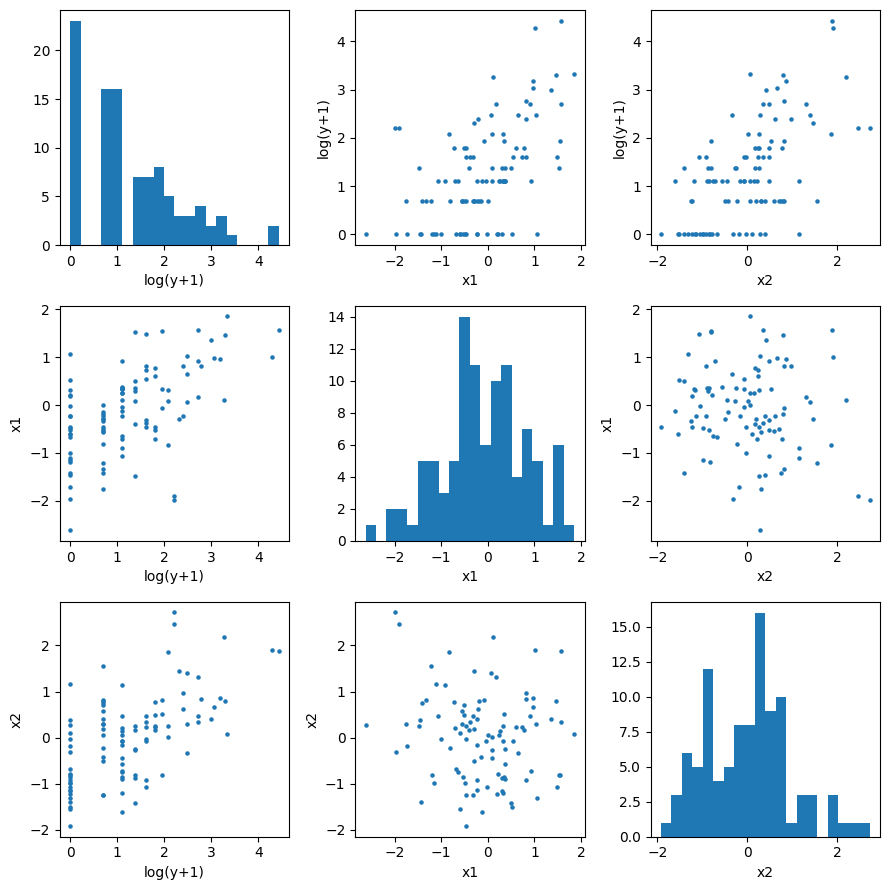

In [34]:
import pandas as pd

data_matrix = np.column_stack([np.log(y + 1), x1, x2])
df = pd.DataFrame(data_matrix, columns=["log(y+1)", "x1", "x2"])

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        if i == j:
            ax.hist(df.iloc[:, i], bins=20)
            ax.set_xlabel(df.columns[i])
        else:
            ax.scatter(df.iloc[:, j], df.iloc[:, i], s=5)
            ax.set_xlabel(df.columns[j])
            ax.set_ylabel(df.columns[i])
plt.tight_layout()

Now lets write out the derivative functions, using the likelihood given earlier in this lecture.  We have $l'(\boldsymbol{\beta}) = \sum_{i=1}^n (y_i - \exp(X_i\boldsymbol{\beta}))\boldsymbol{X}^T_i$ and $l''(\boldsymbol{\beta}) = \sum_{i=1}^n \exp(X_i\boldsymbol{\beta}))\boldsymbol{X}_i\boldsymbol{X}_i^T$

In [35]:
# loglikelihood function
def logLik_reg(beta, y, X):
    lambda_hat = np.exp(X @ beta)
    return np.sum(stats.poisson.logpmf(y, lambda_hat))

# lets write a function for the first derivative
def d1_reg(beta, y, X):
    lambda_hat = np.exp(X @ beta)
    r = y - lambda_hat
    return X.T @ r

# now the second
def d2_reg(beta, y, X):
    lambda_hat = np.exp(X @ beta)
    return -(X.T * lambda_hat) @ X

Now lets apply this:

In [36]:
# the start
tol = 10 ** -4
beta = np.array([np.log(np.mean(y)), 0.0, 0.0])  # multivariate now
maxit = 50
iteration = 0
eps = np.inf

start = time.time()
while eps > tol and iteration < maxit:
    # save the previous value
    beta0 = beta.copy()

    # calculate h, the increment
    h = -np.linalg.solve(d2_reg(beta, y, X), d1_reg(beta, y, X))

    # update beta
    beta = beta + h

    # update the log likelihood
    logL = logLik(np.exp(X @ beta), y)

    # calculate the euclidean distance, could also use the log likelihood if we wanted
    eps = np.sqrt(np.sum((beta - beta0) ** 2))

    # update the iteration number
    iteration += 1
    if iteration == maxit:
        print("Warning: Iteration limit reached without convergence")

    # print out info to keep track
    print(f"Iter: {iteration} logL: {logL:.2f} beta0: {beta[0]:.3f} beta1: {beta[1]:.3f} beta2: {beta[2]:.3f} eps:{eps:.6f}")

end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")

Iter: 1 logL: -681.63 beta0: 1.868 beta1: 1.141 beta2: 1.145 eps:1.618860
Iter: 2 logL: -249.74 beta0: 1.287 beta1: 1.100 beta2: 1.106 eps:0.583198
Iter: 3 logL: -193.26 beta0: 1.039 beta1: 1.050 beta2: 1.057 eps:0.257951
Iter: 4 logL: -191.33 beta0: 1.004 beta1: 1.028 beta2: 1.035 eps:0.046943
Iter: 5 logL: -191.33 beta0: 1.003 beta1: 1.026 beta2: 1.033 eps:0.002314
Iter: 6 logL: -191.33 beta0: 1.003 beta1: 1.026 beta2: 1.033 eps:0.000006
Time elapsed: 0.001081 seconds


Now lets check the result against the `GLM` function in statsmodels

In [37]:
print(beta)
glm_model = sm.GLM(y, X, family=sm.families.Poisson())
glm_fit = glm_model.fit()
print(glm_fit.params)

[1.00349616 1.02599986 1.03332746]
[1.00349616 1.02599986 1.03332746]


We get the same thing

##### Example:  Poisson regression with IRLS

Now lets try IRLS.  We can show $\theta_i = g(\mu_i) = g(\lambda_i)  = \log(\lambda_i)$, $a(\phi) = 1$, and $b(\theta_i) = e^{\theta_i} = \lambda_i$.   Here, $g(\mu_i)$ is the chosen link function for this case, where $g^{-1}(\eta_i) =e^{\eta_i}$.  We can show that this link function, often called the log link function, is also the canonical link function: $$b'(\theta_i) = e^{\theta_i} = g^{-1}(\theta_i),$$  and therefore $\theta_i = \eta_i = \mathbf{X}_i\beta$.

The IRLS update here can be written in general as the following: $$e_i^{(t)} = g'\left(\mu_i^{(t)}\right)(Y_i - \mu_i^{(t)}) = e^{-X_i\boldsymbol{\beta}^{(t)}}\left(Y_i - e^{X_i\boldsymbol{\beta}^{(t)}}\right),$$ $$z_i^{(t)} = \mathbf{X}_i\boldsymbol{\beta}^{(t)} + e_i^{(t)},$$ and a weight value $$w_i^{(t)} =   \left(g'\left(\mu_i^{(t)}\right)^2b''(\theta^{(t)})\alpha(\phi^{(t)})\right)^{-1} =  \left(e^{-2X_i\boldsymbol{\beta}^{(t)}}e^{X_i\boldsymbol{\beta}^{(t)}}\right)^{-1} = e^{X_i\boldsymbol{\beta}^{(t)}}$$. Then, we can solve for $\boldsymbol{\beta}^{(t+1)}$ such that $$\boldsymbol{\beta}^{(t+1)} = (\mathbf{X}^T\mathbf{W}^{(t)}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}^{(t)}z^{(t)},$$ where $\mathbf{W}^{(t)} = diag(w_1^{(t)},\ldots,w_n^{(t)})$ and $z^{(t)} = (z_1^{(t)},\ldots,z_n^{(t)})^T$.



In [38]:
# the start
tol = 10 ** -4
beta = np.array([np.log(np.mean(y)), 0.0, 0.0])  # multivariate now
maxit = 50
iteration = 0
eps = np.inf

start = time.time()
while eps > tol and iteration < maxit:
    # save the previous value
    beta0 = beta.copy()

    # set up values
    # eta
    eta_t = X @ beta0

    # e
    e = np.exp(-eta_t) * (y - np.exp(eta_t))

    # weight vector used in next step
    w = np.exp(eta_t)

    # diagonal weight matrix
    W = np.diag(w)

    # z
    z = eta_t + e

    # solve for beta(t+1)
    beta = np.linalg.solve(X.T @ W @ X, X.T @ W @ z)

    # update the log likelihood
    eta_t1 = X @ beta
    logL = logLik(np.exp(eta_t1), y)

    # calculate the euclidean distance, could also use the log likelihood if we wanted
    eps = np.sqrt(np.sum((beta - beta0) ** 2))

    # update the iteration number
    iteration += 1
    if iteration == maxit:
        print("Warning: Iteration limit reached without convergence")

    # print out info to keep track
    print(f"Iter: {iteration} logL: {logL:.2f} beta0: {beta[0]:.3f} beta1: {beta[1]:.3f} beta2: {beta[2]:.3f} eps:{eps:.6f}")

end = time.time()
print(beta)
print(f"Time elapsed: {end - start:.6f} seconds")

Iter: 1 logL: -681.63 beta0: 1.868 beta1: 1.141 beta2: 1.145 eps:1.618860
Iter: 2 logL: -249.74 beta0: 1.287 beta1: 1.100 beta2: 1.106 eps:0.583198
Iter: 3 logL: -193.26 beta0: 1.039 beta1: 1.050 beta2: 1.057 eps:0.257951
Iter: 4 logL: -191.33 beta0: 1.004 beta1: 1.028 beta2: 1.035 eps:0.046943
Iter: 5 logL: -191.33 beta0: 1.003 beta1: 1.026 beta2: 1.033 eps:0.002314
Iter: 6 logL: -191.33 beta0: 1.003 beta1: 1.026 beta2: 1.033 eps:0.000006
[1.00349616 1.02599986 1.03332746]
Time elapsed: 0.001644 seconds


Again, similar to the previous results.

### Newton-like methods

A wide variety of "Newton-Like" or "Quasi-Newton" approaches exist, where the updating equation takes on a form similar to NR but usually **approximates** the matrix of 2nd derivatives (Hessian).  Here, expressions for only the **first derivatives of the function of interest are needed** and analytical forms for the **second derivatives are not needed**.

This is helpful when the second derivatives may be difficult to derive, have a complicated form, or are computationally expensive to evaluate in practice.

In this class of methods we may write the updating equation as $$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - (\mathbf{M}^{(t)})^{-1}f'(\boldsymbol{\theta}),$$ where $\mathbf{M}^{(t)}$ is a $p\times p$ matrix approximating the Hessian $f''(\boldsymbol{\theta})$ (assuming $\boldsymbol{\theta}$ is a $p$-dimensional vector).

We may choose to do this because either evaluating the Hessian is too computationally expensive, or the steps selected by NR **may not go uphill** (if maximizing), as it is not guaranteed that $f(\boldsymbol{\theta}^{(t+1)}) > f(\boldsymbol{\theta}^{(t)})$ when we are maximizing some function $f(\boldsymbol{\theta})$ (see NR divergence example from earlier).  We will talk about the the method of "steepest ascent/descent" later that tries to ensure improvements in the objective function with each update.

Alternatively, we can choose an $\mathbf{M}^{(t)}$ that can guarantee $f(\boldsymbol{\theta}^{(t+1)}) > f(\boldsymbol{\theta}^{(t)})$ (ascent).  Due to time purposes, we will not cover Discrete Newton, Fixed Point Methods or Gauss-Newton in detail.  However, if interested you can find these topics covered in GH 2.2.2.   We will instead cover more commonly used algorithms such as BFGS (which in general has better performance than the aforementioned methods), Nelder-Mead, gradient descent/ascent, and stochastic gradient descent/ascent.

In general, one may try to avoid calculation of the Hessian matrix by approximating it using an approach akin to the secant-based finite-difference approaches detailed in the univariate maximization portion of this lecture (discrete Newton or fixed point methods also do this).  However, this can become computationally burdensome especially if $M$ is of larger dimension and because of the fact that $M^{(t)}$ may have to be updated at each iteration to ensure faster convergence.

#### Quasi-Newton Methods:  BFGS

Instead, we can use "Quasi-Newton" methods where $M^{(t)}$ is updated with knowledge of the curvature of $f$ in the direction of the proposed step $h^{(t)}$ near $\boldsymbol{\theta}^{(t)}$ while we are performing the update $\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} + h^{(t)}$.  We would like to to avoid computing the approximation of each element the Hessian matrix one-by-one to reduce computational burden.  At the same time, we would also like to retain a similar secant-type condition where $$f'(\theta^{(t+1)}) - f'(\boldsymbol{\theta}^{(t)}) = M^{(t+1)}(\boldsymbol{\theta}^{(t+1)} - \boldsymbol{\theta}^{(t)}),$$ essentially approximating the finite-difference approach using $M^{(t+1)}$.  This equation implies that the specification of some Matrix $\mathbf{M}^{(t+1)}$ times the difference in the estimate of $\boldsymbol{\theta}$ between iterations is equal to the finite difference approximation, preserving the secant condition.   Essentially, we need an approach to generate $\mathbf{M}^{(t+1)}$ from $\mathbf{M}^{(t)}$ that minimizes the number of calculations needed and preserves the above condition.

The question is how do we obtain an $\mathbf{M}^{(t+1)}$ that satisfies this condition and can be determined in a manner that is computationally efficient?  Quasi-Newton (or "variable step") methods are one such approach that can do this when approximating the Hessian at each iteration.  The update to the Hessian has the following form $$\mathbf{M}^{(t+1)} = \mathbf{M}^{(t)} - \frac{\mathbf{M}^{(t)}\mathbf{z}^{(t)}(\mathbf{M}^{(t)}\mathbf{z}^{(t)})^T}{(\mathbf{z}^{(t)})^T\mathbf{M}^{(t)}\mathbf{z}^{(t)}} + \frac{\mathbf{y}^{(t)}(\mathbf{y}^{(t)})^T}{(\mathbf{z}^{(t)})^T\mathbf{y}^{(t)}} + \delta^{(t)}(\mathbf{z}^{(t)})^T\mathbf{M}^{(t)}\mathbf{z}^{(t)})\mathbf{d}^{(t)}(\mathbf{d}^{(t)})^T,$$ where $$\mathbf{d}^{(t)} = \frac{\mathbf{y}^{(t)}}{(\mathbf{z}^{(t)})^T\mathbf{y}^{(t)}} - \frac{\mathbf{M}^{(t)}\mathbf{z}^{(t)}}{(\mathbf{z}^{(t)})^T\mathbf{M}^{(t)}\mathbf{z}^{(t)}},$$

where here $\mathbf{z}^{(t)} = \boldsymbol{\theta}^{(t+1)} - \boldsymbol{\theta}^{(t)}$ and $\mathbf{y}^{(t)} = f'(\boldsymbol{\theta}^{(t+1)}) - f'(\boldsymbol{\theta}^{(t)})$.  This class of algorithms is indexed by the value of $\delta^{(t)}$, where $\delta^{(t)} = 0$ represents the popular BFGS update.  BFGS is generally regarded as the best performing method in this class and is commonly used.  In general, through the use of backtracking (which we will discuss in more detail in the next section) during the calculation of $M^{(t)}$, we can ensure ascent.

Another nice property of BFGS is that the **positive definiteness** of the Hessian approximation is also ensured, meaning that we can take the inverse of this matrix, leading to increase robustness of the method.  If you recall, one of the downsides of NR in the multivariate setting is the lack this guarantee, leading to potential instability of the approach (especially as the dimension grows).  We will touch more on this later.

We won't worry about the specific details regarding how this update was specifically derived.  Many off-the-shelf methods are available implementing this procedure, given a known likelihood function and 1st derivative (we will give an example of this later), so no manual implementation of this approach is necessary. Convergence is slower than than NR (order is between 1 and 2), however BFGS may be potentially faster in terms of overall time, depending on how expensive it is to calculate the hessian in NR.

Lastly, you may more commonly see "L-BFGS-B" in applications instead of BFGS, which is a variant of BFGS that 1)  approximates the Hessian approximation update using a limited amount of computer memory and 2) can place box constraints (bounds) on the parameters be estimated.  The latter is helpful in cases where you want to prevent the algorithm of proposing updates to the parameters that are out of the range of the support for that parameters (for example, values less than or equal zero for $\lambda$ from our simple Poisson example).


#### Tips for improving performance and stability

Performance of BFGS is sensitive to the starting value of $\mathbf{M}^{(0)}$.  For maximum likelihood estimation, it is good to set $\mathbf{M}^{(0)} = -I(\boldsymbol{\theta}^{(0)})$ the negative expected Fisher Information Matrix.  For other problems, setting $\mathbf{M}^{(0)} = -I_{p\times p}$, the negative identity matrix, may work well if all the parameters are on similar scales.

Rescaling parameters is generally helpful if parameters are on very different scales, for example if you have a function $f(\theta_1, \theta_2) = \exp(1+\theta_1) + \theta_2$.  Clearly, similar changes in $\theta_1$ and $\theta_2$ will have very different impacts on $f(\theta_1, \theta_2)$.  This may also prevent the stopping criterion from being influenced by those variables that have the largest units or most influence on the function to be maximized over.  In some cases it may be easier to work with the log or exp of a parameter rather than the original scale of the parameter itself (**reparameterization**). Some transformations also impose a natural lower bound on the parameter space, reducing the need for box constraints.  We will go more in how to do this in the section on `scipy.optimize.minimize`.  More detail is given in Chapter 16 of the Nash book.

#### Pros and Cons for using BFGS:

* Pros
    + Avoids calculation of the Hessian in an efficient manner, while retaining the secant condition
    + Fast and powerful
    + Backtracking approach can ensure ascent
* Cons
    + Not as fast as NR (convergence order between 1 and 2), faster than linear but slower than quadratic convergence
    + Complicated to implement manually, so reliance on off the shelf methods are needed.

#### Examples

In Python, `scipy.optimize.minimize` is a great general purpose solver that employs many of the methods we will discuss in this lecture in one single function. It provides a unified interface for various optimization methods and reports convergence diagnostics.

One thing you might notice is that despite being very common, NR is not listed as one of the options in `scipy.optimize.minimize`. This is mainly due to the hessian matrix potentially not being positive definite in certain cases in NR, which made writing the code to check for these issues quite difficult.  Methods like BFGS avoid some of these issues in the approximated version of the hessian and thus are more stable.

One only needs to pass the objective function, 1st derivative (gradient), and/or second derivative (Hessian) functions to `minimize`, depending on the method requested. The user can also specify options regarding convergence tolerances, max number of iterations and many other things.

One small caveat: `scipy.optimize.minimize` expects the function to **minimize**, so when maximizing a likelihood, we negate the objective function and its gradient.

Lets apply it to the Poisson Regression Example from Earlier:

In [39]:
start = time.time()
result = minimize(
    fun=lambda x: -logLik_reg(x, y, X),  # negate for minimization
    x0=np.array([np.log(np.mean(y)), 0.0, 0.0]),  # initial values
    jac=lambda x: -d1_reg(x, y, X),  # negate gradient too
    method='BFGS',
    options={
        'disp': False,  # higher detail output
        'gtol': tol,
    }
)
end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")
print(result)

Time elapsed: 0.003019 seconds
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 191.32832208670234
        x: [ 1.003e+00  1.026e+00  1.033e+00]
      nit: 11
      jac: [ 4.259e-05  8.141e-05 -5.974e-05]
 hess_inv: [[ 4.408e-03 -1.434e-03 -1.914e-03]
            [-1.434e-03  2.366e-03 -2.041e-04]
            [-1.914e-03 -2.041e-04  2.214e-03]]
     nfev: 16
     njev: 16


### Gradient Descent

Depending on who you talk to, gradient descent may also be referred to as "steepest descent" (as defined in GH). Likewise, it may also be referred to as gradient ascent or "steepest ascent", depending on whether the objective function is being maximized rather than minimized. In other circles, it may refer to a class of methods, which include the methods of "steepest descent" or "steepest ascent" as a special case.

Simply put, steepest ascent replaces $M$ in the previous section with the identity matrix $I$, and  does away with using the hessian or any approximation of it completely. In this manner we completely avoid any computational expense computing/approximating/storing/inverting the hessian, which can get prohibitive in high dimension.  For steepest ascent, it is replaced with $-I$.

That is, the update in this setting is simply $$x^{(t+1)} = x^{(t)} - \alpha^{(t)}f'(x^{(t)}),$$ where $f(x)$ is the function to be minimized.  In this manner, the update takes the direction of steepest descent at $x^{(t)}$.  The step size may be scaled by some value $\alpha^{(t)} > 0$, where if the direction taken at $x^{(t)}$ is negative  $\alpha^{(t)}$ may be halved repeatedly to decrease the step size until a sufficiently small step size finds a downhill route ($\alpha^{(t)}=1$ initially), where "downhill" is determined by the change in the objective function from the original position. This approach is called "backtracking".   A more general version of this approach are "line search" methods, where such methods ensure the change in the objective function is greater than a certain amount and other helpful qualities (detailed in GH 2.2.2.1).  For maximization, flip the sign to $+\alpha^{(t)}f'(x^{(t)})$ in the above expression.

The intuition behind this approach may be described as to trying to find one's way down a hill when blindfolded.  The only information available to you is how steep the hill is at the point where you are standing, and moving in the direction where the slope appears the steepest. We do not have an idea of the curvature (change in the slope) around that point, so we just follow the slope instead.

Gradient Descent, depending on who you talk to, may be thought as a more general form of steepest descent that instead fixes $\alpha^{(t)}$ (sometimes called the "learning rate") rather than letting it vary within each iteration.  In other cases, it is  referred to as a class of methods where both $\alpha^{(t)}$  and the gradient may be scaled with each iteration.

Regardless, the idea is similar in that it avoids computing the hessian and uses the gradient to choose the direction for the next update.  For the same qualities mentioned above, gradient descent is very popular for machine learning methods, particularly for high dimensional problems (no need to store or approximate a $p \times p$ hessian).

However, for very large sample size problems the computation may become prohibitive.  Standard gradient descent described above can be called "batch" gradient descent, where all data points are utilized for computing the next search direction. Lets replace $f'(x^{(t)})$ with $l'(\boldsymbol{\beta}^{(t)})$ where we wish to estimate $\boldsymbol{\beta}$ in the prior Poisson regression example: $$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} + \alpha^{(t)}l'(\boldsymbol{\beta}^{(t)}).$$  One thing that is clear from here is that $$l'(\boldsymbol{\beta}) = \sum_{i=1}^n (y_i - \exp(X_i\boldsymbol{\beta}))X^T_i,$$ which is computed off of $n$ observations.  When $n$ is very large, these updates can become computationally prohibitive.

**An important note** to consider is that the input features are often scaled in GD/SGD to put model parameters on similar ranges, as there is no inverse hessian (or its approximation) to cancel out variations in scale seen in the gradient function due to differences in scale in the original parameters. Instead, the gradient is being multiplied by a constant (learning rate), which is the same for all elements of the gradient function.  This is somewhat similar to why covariates are often standardized prior to the application of penalized likelihood approaches -- that way the same penalty value will approximately mean the same for different coefficients in the model.

### Stochastic Gradient Descent (SGD)

Stochastic gradient descent instead randomly subsamples the data and performs an update for $\boldsymbol{\beta}$ with a random observation drawn from the data.  Rather than updating $\boldsymbol{\beta}$ with a full pass over the data, we instead update $\boldsymbol{\beta}$ with a single draw from the data, such that now $$\boldsymbol{\beta}^{s+1} = \boldsymbol{\beta}^{(s)} - \alpha l_{i(s)}'(\boldsymbol{\beta}^{(s)}),$$ where $s>0$ is the subsample index, $i(s)$ is the index of the sample that is randomly drawn in the $s$th subsample, and $l_{i(s)}'(\boldsymbol{\beta}^{(s)})$ is the value of the gradient computed off of the $i$th subject.  One continues to draw samples until convergence is observed in $\boldsymbol{\beta}^{s+1}$, which may take multiple loops over the entire data set. Other variants include in-order looping across observations rather than random sampling.

Modifications of this approach include "mini-batching", where instead of a single sample drawn from the dataset a group of $m$ samples may be drawn.  This has the effect of reducing variability between iterations and assisting with convergence. While the theoretical convergence rate of SGD is lower than that of GD (SGD is said to be sub-linear), in practice for large $n$ problems it may be much faster, as the per-iteration cost for SGD is much lower than GD in this case. In any case, SGD is obviously helpful in those situations when one cannot read all of the data into memory.

This is also why sometimes GD (as defined in the previous section) is sometimes called **Batch Gradient Descent**, as it requires you to loop over the entire dataset for each update rather than a subsample (mini-batch).

Given the variability from sample to sample, $\alpha^{(t)}$ may held fixed rather than varied, however the convergence and speed is dependent on the optimal selection of this fixed value.  In deep learning and other methods, this value is  often determined through  hyperparameter tuning (tuning parameter selection).  Too large of a learning rate may lead to problems with convergence, and too small may lead to slow convergence. Other approaches  may automatically adjust $\alpha^{(t)}$ as the algorithm is running, decreasing $\alpha^{(t)}$ by some preset schedule (sometimes  called  a "learning rate schedule"). This approach may address some of the shortcomings of fixing $\alpha^{(t)}$, but it is highly dependent on the parameters that determine the rate of decrease as  they are not data adaptive. To address these issues and others, more sophisticated methods for determining $\alpha^{(t)}$ or scaling the gradient during GD/SGD have been proposed such as the ADAM and ADAGRAD optimizers.  You may find more detail on  these approaches [here](https://arxiv.org/abs/1609.04747).

#### Application of GD and SGD to our Poisson Regression Example
Lets try it out on our Poisson regression example.  Here is regular gradient **ascent** (since we are maximizing here) with just a fixed $\alpha^{(t)}$:


In [40]:
# the start
tol = 10**-6
beta = np.array([np.log(np.mean(y)), 0.0, 0.0])  # multivariate now
maxit = 10000
iteration = 0
alpha = 0.0001
eps = np.inf

# given this, the result below will be the same as NR
start = time.time()
while eps > tol and iteration < maxit:
    # save the previous value
    beta0 = beta.copy()

    # calculate h, the increment
    h = alpha * d1_reg(beta, y, X)

    # update beta
    beta = beta + h

    # update the log likelihood
    logL = logLik(np.exp(X @ beta), y)

    # calculate the euclidean distance, could also use the log likelihood if we wanted
    eps = np.sqrt(np.sum((beta - beta0) ** 2))

    # update the iteration number
    iteration += 1
    if iteration == maxit:
        print("Warning: Iteration limit reached without convergence")

    # print out info to keep track
    if iteration % 20 == 0:
        print(f"Iter: {iteration} logL: {logL:.2f} beta0: {beta[0]:.3f} beta1: {beta[1]:.3f} beta2: {beta[2]:.3f} eps:{eps:.6f}")

end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")

Iter: 20 logL: -279.48 beta0: 1.679 beta1: 0.615 beta2: 0.645 eps:0.025019
Iter: 40 logL: -221.90 beta0: 1.464 beta1: 0.805 beta2: 0.813 eps:0.012163
Iter: 60 logL: -204.06 beta0: 1.313 beta1: 0.887 beta2: 0.888 eps:0.007412
Iter: 80 logL: -197.02 beta0: 1.214 beta1: 0.934 beta2: 0.935 eps:0.004792
Iter: 100 logL: -193.97 beta0: 1.149 beta1: 0.963 beta2: 0.966 eps:0.003199
Iter: 120 logL: -192.59 beta0: 1.105 beta1: 0.983 beta2: 0.986 eps:0.002178
Iter: 140 logL: -191.94 beta0: 1.074 beta1: 0.996 beta2: 1.001 eps:0.001502
Iter: 160 logL: -191.63 beta0: 1.053 beta1: 1.005 beta2: 1.010 eps:0.001044
Iter: 180 logL: -191.48 beta0: 1.039 beta1: 1.011 beta2: 1.017 eps:0.000730
Iter: 200 logL: -191.40 beta0: 1.028 beta1: 1.016 beta2: 1.022 eps:0.000513
Iter: 220 logL: -191.36 beta0: 1.021 beta1: 1.019 beta2: 1.025 eps:0.000361
Iter: 240 logL: -191.35 beta0: 1.016 beta1: 1.021 beta2: 1.028 eps:0.000255
Iter: 260 logL: -191.34 beta0: 1.012 beta1: 1.022 beta2: 1.029 eps:0.000180
Iter: 280 logL: 

Takes more iterations and time than some of the prior methods in the low dimensional low sample size setting, but is not surprising since it does not utilize or approximate the hessian.  We could drop this time further by increasing alpha or the convergence threshold, but at the expense of accuracy/convergence.  You can play around with the learning rate parameter to see its impact on convergence.

Now here is a mini batched version of stochastic gradient descent, taking samples of 10


In [41]:
# the start
tol = 10**-8  # lowered threshold to ensure convergence
beta = np.array([np.log(np.mean(y)), 0.0, 0.0])  # multivariate now
maxit = 100000  # increased iteration limit
iteration = 0
alpha = 0.00001
subsample_size = 10
eps = 100000
epscount = 0
logL_history = np.full(maxit, np.nan)

# given this, the result below will be the same as NR
start = time.time()
while eps > tol and iteration < maxit and epscount < 4:
    # save the previous value
    beta0 = beta.copy()

    # take subsample
    index = np.random.choice(n, size=subsample_size, replace=True)

    # calculate h, the increment
    h = alpha * d1_reg(beta, y[index], X[index, :])

    # update beta
    beta = beta + h

    # update the log likelihood
    logL_history[iteration] = logLik(np.exp(X @ beta), y)

    # use relative change in logL from 1000 iterations prior
    # this is because randomness between single iterations large, smooths out
    if iteration > 1000:
        eps = abs(logL_history[iteration] - logL_history[iteration - 1000]) / abs(logL_history[iteration - 1000])

    # we use this count to protect against randomly hitting the convergence limit early
    if eps < tol:
        epscount += 1

    # update the iteration number
    iteration += 1
    if iteration == maxit:
        print("Warning: Iteration limit reached without convergence")

    # print out info to keep track
    if iteration % 1000 == 0:
        print(f"Iter: {iteration} logL: {logL_history[iteration-1]:.2f} beta0: {beta[0]:.3f} beta1: {beta[1]:.3f} beta2: {beta[2]:.3f} eps:{eps:.6f}")

end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")

Iter: 1000 logL: -399.01 beta0: 1.756 beta1: 0.372 beta2: 0.401 eps:100000.000000
Iter: 2000 logL: -283.84 beta0: 1.683 beta1: 0.603 beta2: 0.631 eps:0.288632
Iter: 3000 logL: -242.60 beta0: 1.574 beta1: 0.730 beta2: 0.748 eps:0.145276
Iter: 4000 logL: -223.00 beta0: 1.473 beta1: 0.801 beta2: 0.811 eps:0.080803
Iter: 5000 logL: -211.58 beta0: 1.389 beta1: 0.850 beta2: 0.856 eps:0.051227
Iter: 6000 logL: -204.60 beta0: 1.321 beta1: 0.887 beta2: 0.888 eps:0.032983
Iter: 7000 logL: -200.17 beta0: 1.263 beta1: 0.912 beta2: 0.910 eps:0.021627
Iter: 8000 logL: -197.34 beta0: 1.219 beta1: 0.930 beta2: 0.932 eps:0.014155
Iter: 9000 logL: -195.50 beta0: 1.182 beta1: 0.946 beta2: 0.945 eps:0.009335
Iter: 10000 logL: -194.23 beta0: 1.150 beta1: 0.959 beta2: 0.957 eps:0.006496
Iter: 11000 logL: -193.41 beta0: 1.126 beta1: 0.968 beta2: 0.967 eps:0.004231
Iter: 12000 logL: -192.76 beta0: 1.109 beta1: 0.980 beta2: 0.980 eps:0.003334
Iter: 13000 logL: -192.33 beta0: 1.093 beta1: 0.988 beta2: 0.989 eps

Again, it takes longer to achieve sufficient accuracy, but in much higher dimension and sample size this would be faster than alternative approaches.

### Nelder-Mead

In certain situations we may find that neither the first nor the second derivative may be easily derived or easy to evaluate computationally.  Nelder-Mead, sometimes called the "Simplex Search Method" is one such algorithm that **only requires the specification and evaluation of the function in question** $f(\boldsymbol{\theta})$ in order to perform optimization. Hence this algorithm falls into the class of iterative "direct search" algorithms as it only evaluates the function at possible solutions to suggest a better place for the algorithm to move to in the parameter space.

In the maximum likelihood estimation context, this means that only the likelihood function is evaluated during optimization.  This method may also be applied in more general situations where only some objective function exists that you wish to maximize or minimize but not clear analytical derivatives exists.

Prior descriptions of this algorithm describe it as "amoeba-like", where the algorithm sequentially updates the "best" set of model parameters, crawling uphill or downhill in terms of the objective function surface until it reaches and optimal set of parameters.  The specific algorithm and its development are somewhat out of the scope of this course, however we will cover it briefly here.

The main ideas behind this approach is similar to the prior two classes of algorithms covered so far, where the algorithm starts from an initial set of guesses for the parameter estimates, and then iteratively updates until some convergence criteria is met.

#### Updating algorithm
The basic idea behind this algorithm is based upon the definition of the "simplex". The $p+1$ elements of the simplex contains a $p$ dimensional vector representing a particular combination of the $p$ parameter values.  Each one of these $p$ combinations represent a "vertex" in the simplex space.  The method begins from set of initial vertices in the simplex based upon $\boldsymbol{\theta}^{(0)}$ through a predefined algorithm.  These vertices are then ranked from best to worst in terms of their function value, updating the worst rank vertex each time.  In general, the worst vertex is updated towards the direction of the best vertices in the simplex.

In this iterative fashion, the vertices in the simplex slowly start to move towards regions of higher value until no further updates to the parameters results in an appreciable increase in the objective function.  The simplex may also "shrink" in size to better encapsulate regions of higher values when proposed moves in the simplex do not result in significant improvements in the objective function.  In general, the algorithm in each iteration tries to improve the worst point in the simplex (corresponding to a single parameter in the original model).

The details of this updating procedure is given in GH 2.2.4, however we illustrate this graphically in the video below pertaining to the optimization of a 2D model (containing two parameters).

[Nelder-Mead Simplex Method Visualization (YouTube)](https://www.youtube.com/watch?v=j2gcuRVbwR0)

#### Convergence

Relative or absolute convergence criteria may be based upon the objective function values at each iteration of the algorithm or based on the volume of the simplex at the given set of vertices.

#### Pros and Cons
* Pros
    + Does not require 1st or 2nd derivatives
    + Robust:  can be applied to a wide range of algorithms, rare failures
* Cons
    + Typically requires many more iterations for convergence, and therefore may not be optimal for large-scale testing problems.
    + Difficult to implement manually but many off-the-shelf solutions exist (such as `scipy.optimize.minimize` in Python)
    + Not suitable for high dimensional problems
    + Does not directly provide Hessian, but can be calculated after convergence

#### Examples

In [42]:
start = time.time()
result = minimize(
    fun=lambda x: -logLik_reg(x, y, X),  # negate for minimization
    x0=np.array([np.log(np.mean(y)), 0.0, 0.0]),  # initial values
    method='Nelder-Mead',
    options={
        'disp': False,
        'xatol': tol,
        'fatol': tol,
    }
)
end = time.time()
print(f"Time elapsed: {end - start:.6f} seconds")
print(result)

Time elapsed: 0.011009 seconds
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 191.32832208668768
             x: [ 1.003e+00  1.026e+00  1.033e+00]
           nit: 168
          nfev: 301
 final_simplex: (array([[ 1.003e+00,  1.026e+00,  1.033e+00],
                       [ 1.003e+00,  1.026e+00,  1.033e+00],
                       [ 1.003e+00,  1.026e+00,  1.033e+00],
                       [ 1.003e+00,  1.026e+00,  1.033e+00]]), array([ 1.913e+02,  1.913e+02,  1.913e+02,  1.913e+02]))


Another popular gradient-free method is the **BOBYQA** optimizer. In Python, `scipy.optimize` provides similar derivative-free methods such as Powell's method and COBYLA.

## For more detail

See Givens and Hoeting Chapters 1 and 2

Nonlinear Parameter Optimization Using R Tools (John Nash)